<a href="https://colab.research.google.com/github/Sandesh18-tech/Titanic-Dataset/blob/main/titanic_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read Dataset
df = pd.read_csv("Titanic-Dataset.csv")

# Display first 5 rows
print(df.head())

# Dataset Information
print("\nDataset Info:")
print(df.info())

# Shape of Dataset
print("\nShape:", df.shape)

# Statistical Summary
print("\nSummary Statistics:")
print(df.describe())

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Check Duplicate Records
print("\nDuplicate Records:", df.duplicated().sum())

# Data Types
print("\nData Types:")
print(df.dtypes)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  

D

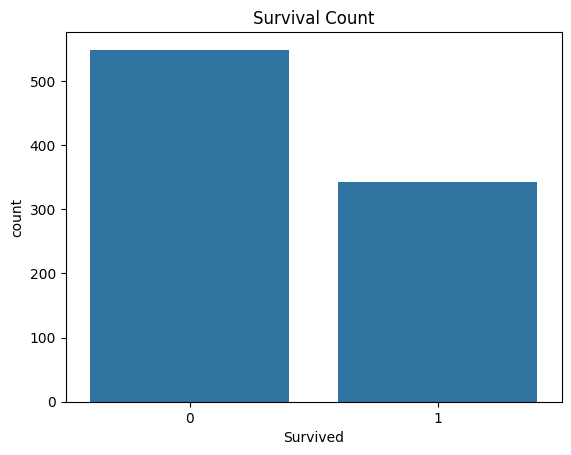

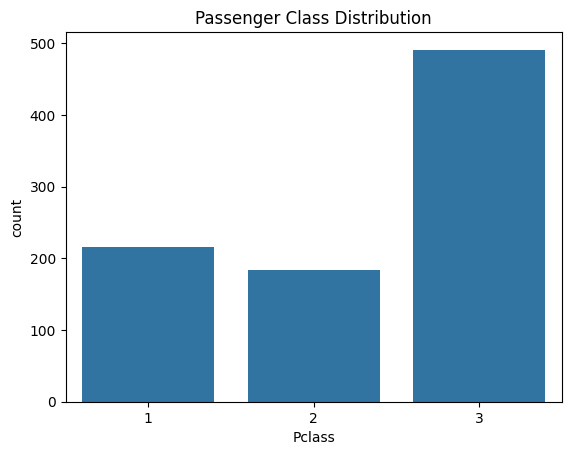

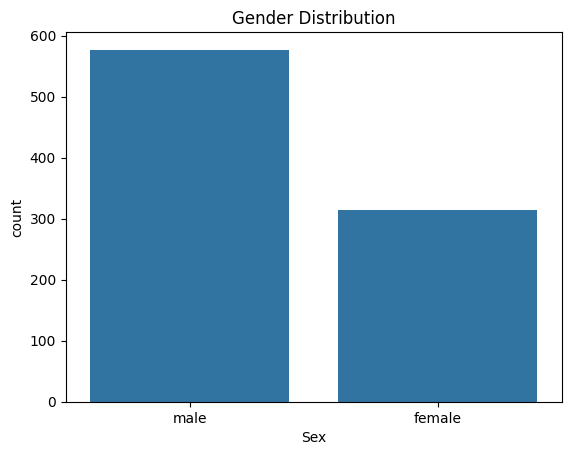

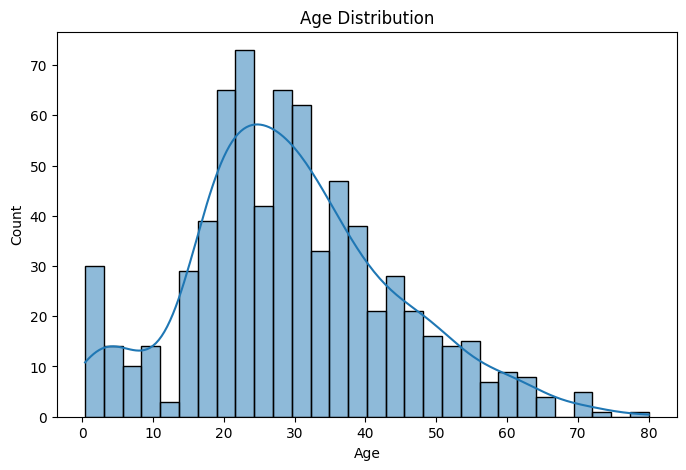

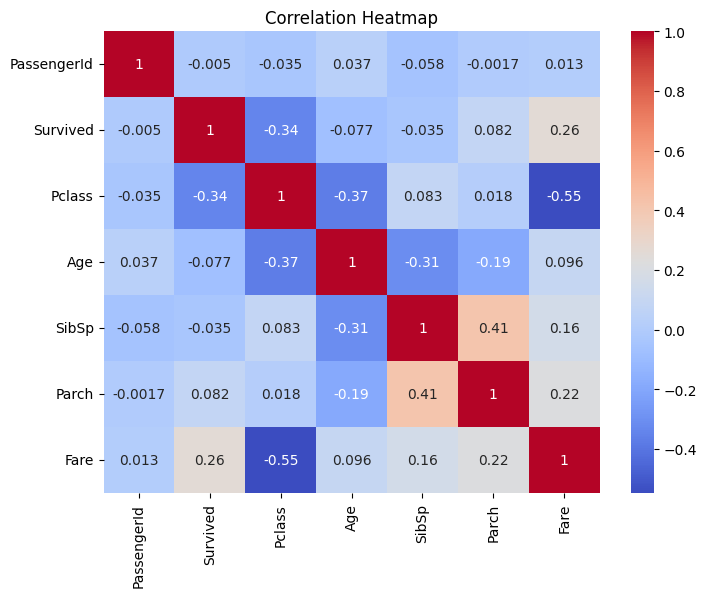

In [2]:
# Survival Count
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

# Passenger Class Distribution
sns.countplot(x='Pclass', data=df)
plt.title("Passenger Class Distribution")
plt.show()

# Gender Distribution
sns.countplot(x='Sex', data=df)
plt.title("Gender Distribution")
plt.show()

# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [3]:
# Select two rows for comparison
obj1 = df.loc[0, ['Sex','Embarked']]
obj2 = df.loc[1, ['Sex','Embarked']]

print("Object 1")
print(obj1)

print("\nObject 2")
print(obj2)

# Simple Matching Dissimilarity
matches = sum(obj1 == obj2)
total = len(obj1)

dissimilarity = (total - matches) / total

print("\nNominal Attribute Dissimilarity =", dissimilarity)

Object 1
Sex         male
Embarked       S
Name: 0, dtype: object

Object 2
Sex         female
Embarked         C
Name: 1, dtype: object

Nominal Attribute Dissimilarity = 1.0


In [4]:
# Select two rows
x = df.loc[0, ['Age','Fare']].fillna(0).values
y = df.loc[1, ['Age','Fare']].fillna(0).values

# Euclidean Distance
distance = np.sqrt(np.sum((x - y)**2))

print("Passenger 1:", x)
print("Passenger 2:", y)

print("\nEuclidean Distance =", distance)

Passenger 1: [22.    7.25]
Passenger 2: [38.     71.2833]

Euclidean Distance = 66.00199624928021


/tmp/ipykernel_1201/2566518415.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x = df.loc[0, ['Age','Fare']].fillna(0).values
/tmp/ipykernel_1201/2566518415.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df.loc[1, ['Age','Fare']].fillna(0).values


In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances

# Read dataset
df = pd.read_csv("Titanic-Dataset.csv")

# Select numeric attributes
data = df[['Age', 'Fare']]

# Replace missing values with mean
data = data.fillna(data.mean())

# Take first 5 records for simplicity
data = data.head(5)

# Euclidean Distance Matrix
distance_matrix = euclidean_distances(data)

# Similarity Matrix
similarity_matrix = 1 / (1 + distance_matrix)

print("Euclidean Distance Matrix:")
print(pd.DataFrame(distance_matrix))

print("\nSimilarity Matrix:")
print(pd.DataFrame(similarity_matrix))

Euclidean Distance Matrix:
           0          1          2          3          4
0   0.000000  66.001996   4.056553  47.657345  13.024592
1  66.001996   0.000000  64.484682  18.429118  63.304425
2   4.056553  64.484682   0.000000  46.062790   9.000868
3  47.657345  18.429118  46.062790   0.000000  45.050000
4  13.024592  63.304425   9.000868  45.050000   0.000000

Similarity Matrix:
          0         1         2         3         4
0  1.000000  0.014925  0.197763  0.020552  0.071303
1  0.014925  1.000000  0.015271  0.051469  0.015551
2  0.197763  0.015271  1.000000  0.021248  0.099991
3  0.020552  0.051469  0.021248  1.000000  0.021716
4  0.071303  0.015551  0.099991  0.021716  1.000000


In [6]:
import pandas as pd
import numpy as np

# Read dataset
df = pd.read_csv("Titanic-Dataset.csv")

# Fill missing Age values
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Select Age and Fare of first two passengers
p1 = df.loc[0, ['Age', 'Fare']].values
p2 = df.loc[1, ['Age', 'Fare']].values

# Euclidean Distance
distance = np.sqrt(np.sum((p1 - p2) ** 2))

print("Passenger 1:", p1)
print("Passenger 2:", p2)
print("Euclidean Distance =", distance)

Passenger 1: [np.float64(22.0) np.float64(7.25)]
Passenger 2: [np.float64(38.0) np.float64(71.2833)]
Euclidean Distance = 66.00199624928021
